Loan NN modeling

In [67]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import pickle

In [40]:
df= pd.read_csv("../data/loan_encoded.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0.0,0.0,1.0
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1.0,0.0,0.0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0.0,0.0,1.0
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0.0,0.0,1.0
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0.0,0.0,1.0


In [41]:
df.isna().sum()

Loan_ID                     0
Gender                      0
Married                     0
Dependents                  0
Education                   0
Self_Employed               0
ApplicantIncome             0
CoapplicantIncome           0
LoanAmount                  0
Loan_Amount_Term            0
Credit_History              0
Loan_Status                 0
Property_Area_Rural        11
Property_Area_Semiurban    11
Property_Area_Urban        11
dtype: int64

In [42]:
df.shape

(603, 15)

In [43]:
df["Property_Area_Rural"] = df["Property_Area_Rural"].ffill()
df["Property_Area_Semiurban"] = df["Property_Area_Semiurban"].ffill()
df["Property_Area_Urban"] = df["Property_Area_Urban"].ffill()

In [44]:
df.isna().sum()

Loan_ID                    0
Gender                     0
Married                    0
Dependents                 0
Education                  0
Self_Employed              0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Loan_Status                0
Property_Area_Rural        0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64

Feature Selection

In [45]:
df.drop(columns=["Loan_ID"], inplace=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0.0,0.0,1.0
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1.0,0.0,0.0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0.0,0.0,1.0
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0.0,0.0,1.0
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0.0,0.0,1.0


MinMax Scaler

In [46]:
columns_to_scale = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

scaler = MinMaxScaler(clip=True)
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,0.240942,0.000000,0.185647,0.74359,1.0,1,0.0,0.0,1.0
1,1,1,1,1,0,0.187418,0.133451,0.185647,0.74359,1.0,0,1.0,0.0,0.0
2,1,1,0,1,1,0.120492,0.000000,0.088924,0.74359,1.0,1,0.0,0.0,1.0
3,1,1,0,0,0,0.102862,0.208673,0.173167,0.74359,1.0,1,0.0,0.0,1.0
4,1,0,0,1,0,0.247326,0.000000,0.205928,0.74359,1.0,1,0.0,0.0,1.0


Training NN model

In [47]:
#Split the data to train and test
x = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]

x_train,x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [48]:
x_test

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
110,1,0,0,1,0,0.218408,0.000000,0.198128,0.74359,1.0,0.0,0.0,1.0
527,1,1,0,1,0,0.252949,0.345664,0.491420,0.74359,1.0,1.0,0.0,0.0
567,1,1,0,1,0,0.124170,0.195575,0.198128,0.74359,0.0,0.0,0.0,1.0
77,1,1,1,1,1,0.035936,0.267434,0.157566,0.74359,1.0,0.0,0.0,1.0
181,0,1,0,1,0,0.146916,0.000000,0.154446,0.74359,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,1,1,0,1,0,0.099311,0.217522,0.235569,0.74359,1.0,0.0,1.0,0.0
148,0,0,0,1,0,0.416438,0.147434,0.336973,0.74359,1.0,1.0,0.0,0.0
496,1,1,2,1,0,0.142054,0.390796,0.365055,0.74359,1.0,1.0,0.0,0.0
441,1,1,2,0,0,0.091278,0.111062,0.180967,0.74359,0.0,0.0,1.0,0.0


In [49]:
x_test.shape

(121, 13)

In [50]:
y_test

110    1
527    1
567    0
77     0
181    1
      ..
340    1
148    0
496    1
441    0
145    1
Name: Loan_Status, Length: 121, dtype: int64

In [51]:
y_test.shape

(121,)

In [52]:
#Load MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(80,60,30,20), random_state=42, max_iter=2000, 
                      early_stopping=True, verbose=True, n_iter_no_change=50, solver='adam', tol=0.00001)

In [53]:
model.fit(x_train, y_train)

Iteration 1, loss = 0.66300623
Validation score: 0.693878
Iteration 2, loss = 0.64765282
Validation score: 0.693878
Iteration 3, loss = 0.64057201
Validation score: 0.693878
Iteration 4, loss = 0.63404792
Validation score: 0.693878
Iteration 5, loss = 0.62682267
Validation score: 0.693878
Iteration 6, loss = 0.61754232
Validation score: 0.693878
Iteration 7, loss = 0.60722619
Validation score: 0.693878
Iteration 8, loss = 0.59746079
Validation score: 0.693878
Iteration 9, loss = 0.58613464
Validation score: 0.693878
Iteration 10, loss = 0.57696603
Validation score: 0.714286
Iteration 11, loss = 0.56586541
Validation score: 0.775510
Iteration 12, loss = 0.55767856
Validation score: 0.775510
Iteration 13, loss = 0.54947444
Validation score: 0.795918
Iteration 14, loss = 0.53771031
Validation score: 0.795918
Iteration 15, loss = 0.53013666
Validation score: 0.795918
Iteration 16, loss = 0.51895969
Validation score: 0.857143
Iteration 17, loss = 0.50783721
Validation score: 0.918367
Iterat

,hidden_layer_sizes,"(80, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True
,random_state,42


Loss curve

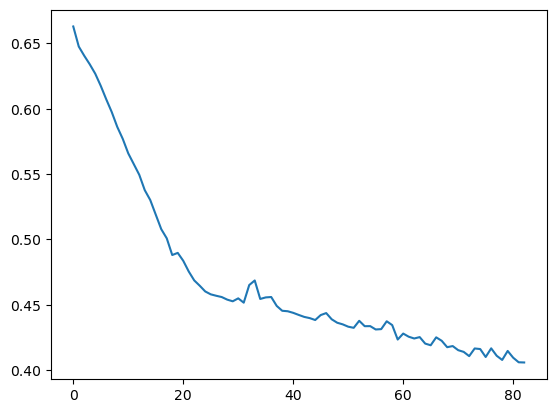

In [54]:
loss_curve = model.loss_curve_
plt.plot(loss_curve)
plt.show()

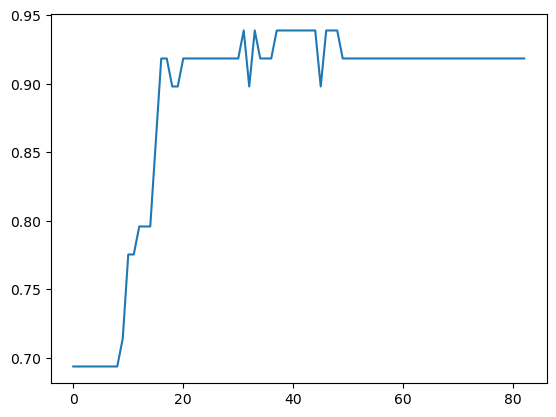

In [55]:
validation_score = model.validation_scores_
plt.plot(validation_score)
plt.show()

Model weights & biais

In [56]:
model.coefs_

[array([[-0.06428393,  0.24183873,  0.17308198, ..., -0.19261243,
         -0.0305229 , -0.20258204],
        [ 0.21101282,  0.10070912, -0.03401391, ...,  0.15873731,
         -0.08096114,  0.10496347],
        [-0.05457334,  0.08609991,  0.11183796, ..., -0.17549932,
          0.03198739, -0.17432576],
        ...,
        [ 0.05374286, -0.22796626,  0.09229051, ...,  0.14227733,
         -0.18025716, -0.134031  ],
        [-0.10466081,  0.13316128, -0.18805697, ..., -0.231564  ,
         -0.11373612,  0.11392522],
        [-0.16420356,  0.10312939, -0.10247308, ...,  0.09873945,
         -0.16174531, -0.08144492]], shape=(13, 80)),
 array([[ 0.10587288,  0.13851172,  0.13224209, ..., -0.15441688,
          0.11467897,  0.04972662],
        [ 0.13431707, -0.03745826,  0.03938646, ..., -0.0143576 ,
          0.24363091, -0.09008781],
        [ 0.09828915,  0.19244788,  0.10864137, ..., -0.13019571,
          0.12263988,  0.10798667],
        ...,
        [ 0.10671543,  0.04136562,  0.

In [57]:
model.intercepts_

[array([ 3.04515010e-02,  1.72784841e-01, -2.83986741e-02,  3.96692686e-02,
         2.13991430e-01,  7.41891709e-02, -1.64930044e-01, -2.14609508e-01,
         1.64553357e-01, -2.08910367e-01,  2.33357510e-01,  3.07110037e-02,
         2.41338004e-01,  1.35002648e-01,  2.69581390e-01, -8.83880472e-02,
         1.69214771e-01, -5.02362370e-02, -1.56159747e-03,  7.25872614e-02,
         2.36657318e-01,  2.31385904e-01,  1.47749670e-01, -9.63217683e-03,
         6.80739448e-04,  1.02812677e-01, -1.28243458e-01, -1.89886737e-01,
        -7.74307194e-02, -1.08082700e-01, -4.22663675e-02, -1.45277095e-01,
        -2.39788972e-01, -2.10489668e-01,  2.86953944e-01, -7.39152755e-02,
        -7.83061339e-02,  8.16889825e-02, -1.54222461e-01,  2.54844717e-01,
         1.83370625e-01, -1.89897168e-01, -1.62362181e-02,  2.37383914e-01,
         2.59807178e-01, -1.41657248e-05,  3.02026692e-02, -1.73361946e-01,
         2.31798487e-01, -1.45591277e-01,  2.36824132e-01,  8.12638475e-02,
         7.0

Testing

In [58]:
sample_record = x_test.sample(3)
sample_record

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
402,1,1,1,1,0,0.344565,0.000000,0.223089,0.615385,0.0,0.0,0.0,1.0
540,1,1,0,1,0,0.111402,0.178407,0.157566,0.743590,1.0,0.0,1.0,0.0
24,1,1,1,1,0,0.150805,0.258850,0.221529,0.743590,1.0,0.0,1.0,0.0


In [59]:
result = model.predict(sample_record)
result

array([0, 1, 1])

Evaluation

In [61]:
predictions = model.predict(x_test)
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
cm

array([[14, 23],
       [ 1, 83]])

<function matplotlib.pyplot.show(close=None, block=None)>

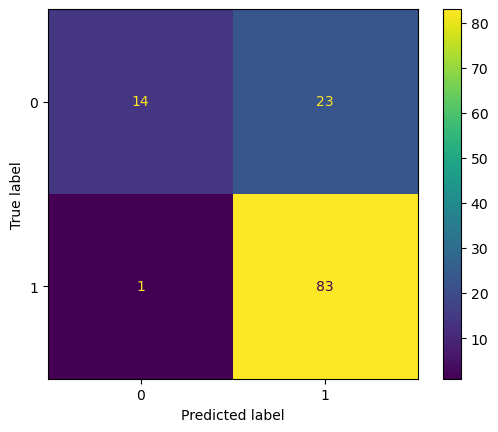

In [63]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= model.classes_)
disp.plot()
plt.show

In [64]:
#f1_score
f1_score = f1_score(y_test, predictions)
f1_score

0.8736842105263158

Saving the model

In [65]:
model.feature_names_in_

array(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area_Rural',
       'Property_Area_Semiurban', 'Property_Area_Urban'], dtype=object)

In [68]:
pickle.dump(model, open("../object/loanmodel.pkl", "wb"))